<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/RNN/wikitext2_rnn_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WikiText-2 语言建模与文本预测 - TensorFlow/Keras RNN 实现

本教程将指导你使用 TensorFlow/Keras 构建循环神经网络（RNN）模型来进行语言建模任务，使用 WikiText-2 数据集。

## 学习目标
- 理解 Keras 在序列建模中的高级 API 优势
- 掌握 TensorFlow 中文本数据的处理流水线
- 学习使用 Keras 回调函数优化训练过程
- 了解 TensorFlow/Keras 的模型保存和部署特性

## 语言建模任务简介
语言建模是预测文本序列中下一个词汇的任务，是自然语言处理的基础。通过学习大量文本数据中词汇的上下文关系，模型可以：

- **理解语言规律**：掌握语法、语义和上下文关系
- **生成流畅文本**：创作连贯的文章、对话和创意内容
- **支持下游任务**：为机器翻译、问答系统等提供基础
- **评估语言能力**：通过困惑度等指标衡量模型性能

## TensorFlow/Keras 的优势
- **简洁的 API**：高级抽象让模型构建更直观
- **丰富的层类型**：内置多种 RNN 变体（LSTM、GRU 等）
- **强大的回调系统**：便于实现复杂的训练策略
- **可视化支持**：TensorBoard 集成和模型可视化
- **生产部署**：TensorFlow Serving 和 TFLite 部署支持

https://huggingface.co/datasets/mindchain/wikitext2

https://sssaha.github.io/posts/2019/12/gru-formula/

WikiText-2是一个**英文语言建模数据集**，主要用于训练和评估语言模型。以下是详细介绍：

## 基本信息
- **来源**：从维基百科经过验证的优质和特色文章中提取，包含超过1亿个token
- **许可**：Creative Commons Attribution-ShareAlike License (CC BY-SA 4.0)
- **发布年份**：2016年，由Stephen Merity等人在论文"Pointer Sentinel Mixture Models"中提出

## 数据集特点

**规模对比：**
- 与Penn Treebank (PTB)相比，WikiText-2大2倍以上
- WikiText-2的设计目标是与PTB规模相似

**数据质量优势：**
- 保留原始大小写、标点符号和数字（PTB中这些都被移除了）
- 具有更大的词汇表
- 由完整文章组成，适合需要利用长期依赖关系的模型

## 文件结构
数据集包含以下文件：
- wiki.train.tokens（训练集）
- wiki.valid.tokens（验证集）  
- wiki.test.tokens（测试集）

提供两种版本：
- Raw版本：用于字符级处理
- Non-raw版本：用于词级处理，只包含词汇表中的token

## 主要用途
1. **语言建模** - 训练能够预测下一个词的模型
2. **预训练语言模型** - 作为大规模预训练的语料
3. **长期依赖建模** - 研究模型处理长文本的能力
4. **基准测试** - 评估不同语言模型的性能

## 数据示例
数据集包含各种维基百科文章内容，如关于金币、超级马里奥、计算器等主题的完整文章段落。

这个数据集是自然语言处理领域的标准基准之一，广泛用于语言模型的训练和评估。

## 1. 导入必要的库

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# 数据处理和可视化
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
import re
import math
import time
import warnings
warnings.filterwarnings('ignore')

# 尝试导入 tensorflow_datasets
try:
    import tensorflow_datasets as tfds
    TFDS_AVAILABLE = True
    print("tensorflow_datasets 可用")
except ImportError:
    TFDS_AVAILABLE = False
    print("tensorflow_datasets 不可用，将使用替代方案")

# 配置 matplotlib 中文显示
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
# plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以确保结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 检查 TensorFlow 版本和 GPU 可用性
print(f'TensorFlow 版本: {tf.__version__}')
print(f'Keras 版本: {keras.__version__}')
print(f'可用 GPU 数量: {len(tf.config.list_physical_devices("GPU"))}')

# 配置 GPU 内存增长（如果有 GPU）
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU 配置成功: {gpus[0].name}')
    except RuntimeError as e:
        print(f'GPU 配置错误: {e}')
else:
    print('使用 CPU 进行训练')

tensorflow_datasets 可用
TensorFlow 版本: 2.19.0
Keras 版本: 3.10.0
可用 GPU 数量: 0
使用 CPU 进行训练


## 2. 数据加载与预处理

我们将使用 TensorFlow Datasets 加载 WikiText-2，如果不可用则使用替代的数据加载方案。

In [2]:
def load_wikitext2_data():
    """
    加载 WikiText-2 数据集
    优先使用 tensorflow_datasets，如果不可用则使用替代方案
    """
    if TFDS_AVAILABLE:
        try:
            print('使用 tensorflow_datasets 加载 WikiText-2...')
            # 加载数据集
            ds = tfds.load('wikitext/wikitext-2-v1', split=['train', 'validation', 'test'])
            train_ds, valid_ds, test_ds = ds

            # 提取文本
            train_texts = []
            for example in train_ds:
                text = example['text'].numpy().decode('utf-8')
                if text.strip() and not text.startswith('='):  # 过滤空行和标题
                    train_texts.append(text.strip())

            valid_texts = []
            for example in valid_ds:
                text = example['text'].numpy().decode('utf-8')
                if text.strip() and not text.startswith('='):
                    valid_texts.append(text.strip())

            test_texts = []
            for example in test_ds:
                text = example['text'].numpy().decode('utf-8')
                if text.strip() and not text.startswith('='):
                    test_texts.append(text.strip())

            return train_texts, valid_texts, test_texts

        except Exception as e:
            print(f'tensorflow_datasets 加载失败: {e}')
            print('使用替代数据...')

    # 替代方案：使用模拟的文本数据
    print('使用模拟的英文文本数据...')

    # 创建一些示例文本数据
    sample_texts = [
        "The history of artificial intelligence began in antiquity with myths stories and rumors.",
        "Computer science is the study of computation and computer systems.",
        "Machine learning is a branch of artificial intelligence and computer science.",
        "Deep learning is part of a broader family of machine learning methods.",
        "Neural networks are computing systems inspired by biological neural networks.",
        "Natural language processing is a subfield of linguistics and artificial intelligence.",
        "The field of computer vision seeks to automate tasks that human visual system can do.",
        "Data science is an interdisciplinary field that uses scientific methods and algorithms.",
        "Python is a high-level programming language for general-purpose programming.",
        "TensorFlow is an open-source software library for machine learning applications."
    ] * 100  # 重复以增加数据量

    # 简单的数据划分
    train_size = int(0.8 * len(sample_texts))
    valid_size = int(0.1 * len(sample_texts))

    train_texts = sample_texts[:train_size]
    valid_texts = sample_texts[train_size:train_size + valid_size]
    test_texts = sample_texts[train_size + valid_size:]

    return train_texts, valid_texts, test_texts

# 加载数据
train_texts, valid_texts, test_texts = load_wikitext2_data()

print(f'训练文本数量: {len(train_texts)}')
print(f'验证文本数量: {len(valid_texts)}')
print(f'测试文本数量: {len(test_texts)}')
print('\n前3个训练样本:')
for i, text in enumerate(train_texts[:3]):
    print(f'{i+1}. {text[:100]}...')

使用 tensorflow_datasets 加载 WikiText-2...
tensorflow_datasets 加载失败: Dataset wikitext not found.
Available datasets:
	- abstract_reasoning
	- accentdb
	- aeslc
	- aflw2k3d
	- ag_news_subset
	- ai2_arc
	- ai2_arc_with_ir
	- ai2dcaption
	- aloha_mobile
	- amazon_us_reviews
	- anli
	- answer_equivalence
	- arc
	- asimov_dilemmas_auto_val
	- asimov_dilemmas_scifi_train
	- asimov_dilemmas_scifi_val
	- asimov_injury_val
	- asimov_multimodal_auto_val
	- asimov_multimodal_manual_val
	- asqa
	- asset
	- assin2
	- asu_table_top_converted_externally_to_rlds
	- austin_buds_dataset_converted_externally_to_rlds
	- austin_sailor_dataset_converted_externally_to_rlds
	- austin_sirius_dataset_converted_externally_to_rlds
	- bair_robot_pushing_small
	- bc_z
	- bccd
	- beans
	- bee_dataset
	- beir
	- berkeley_autolab_ur5
	- berkeley_cable_routing
	- berkeley_fanuc_manipulation
	- berkeley_gnm_cory_hall
	- berkeley_gnm_recon
	- berkeley_gnm_sac_son
	- berkeley_mvp_converted_externally_to_rlds
	- berkeley_rpt_

In [3]:
def preprocess_texts(texts, max_vocab_size=10000):
    """
    预处理文本数据

    Args:
        texts: 文本列表
        max_vocab_size: 最大词汇表大小

    Returns:
        tokenizer: 训练好的分词器
        sequences: 数字序列
    """
    # 文本预处理
    processed_texts = []
    for text in texts:
        # 转换为小写并移除多余空格
        text = re.sub(r'\s+', ' ', text.lower().strip())
        if len(text) > 0:
            processed_texts.append(text)

    # 创建并训练分词器
    tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<UNK>')
    tokenizer.fit_on_texts(processed_texts)

    # 转换为序列
    sequences = tokenizer.texts_to_sequences(processed_texts)

    return tokenizer, sequences

# 预处理所有文本数据
print('预处理训练数据...')
tokenizer, train_sequences = preprocess_texts(train_texts)

print('预处理验证数据...')
_, valid_sequences = preprocess_texts(valid_texts)
valid_sequences = tokenizer.texts_to_sequences([re.sub(r'\s+', ' ', text.lower().strip())
                                               for text in valid_texts])

print('预处理测试数据...')
_, test_sequences = preprocess_texts(test_texts)
test_sequences = tokenizer.texts_to_sequences([re.sub(r'\s+', ' ', text.lower().strip())
                                              for text in test_texts])

# 词汇表信息
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding
print(f'\n词汇表大小: {vocab_size}')
print(f'最常见的10个词:')
word_freq = list(tokenizer.word_counts.items())[:10]
for word, freq in word_freq:
    print(f'  {word}: {freq}')

# 序列统计
all_sequences = train_sequences + valid_sequences + test_sequences
seq_lengths = [len(seq) for seq in all_sequences if len(seq) > 0]

print(f'\n序列长度统计:')
print(f'平均长度: {np.mean(seq_lengths):.1f}')
print(f'中位数长度: {np.median(seq_lengths):.1f}')
print(f'最大长度: {max(seq_lengths) if seq_lengths else 0}')
print(f'最小长度: {min(seq_lengths) if seq_lengths else 0}')

# 显示一些序列示例
print('\n序列示例:')
for i, seq in enumerate(train_sequences[:3]):
    if len(seq) > 0:
        words = [list(tokenizer.word_index.keys())[list(tokenizer.word_index.values()).index(idx)]
                for idx in seq[:10] if idx <= len(tokenizer.word_index)]
        print(f'{i+1}. 数字序列: {seq[:10]}')
        print(f'   对应词汇: {words}')

预处理训练数据...
预处理验证数据...
预处理测试数据...

词汇表大小: 73
最常见的10个词:
  the: 240
  history: 80
  of: 560
  artificial: 240
  intelligence: 240
  began: 80
  in: 80
  antiquity: 80
  with: 80
  myths: 80

序列长度统计:
平均长度: 11.6
中位数长度: 11.0
最大长度: 15
最小长度: 10

序列示例:
1. 数字序列: [8, 23, 2, 9, 10, 24, 25, 26, 27, 28]
   对应词汇: ['the', 'history', 'of', 'artificial', 'intelligence', 'began', 'in', 'antiquity', 'with', 'myths']
2. 数字序列: [5, 11, 3, 8, 31, 2, 32, 4, 5, 13]
   对应词汇: ['computer', 'science', 'is', 'the', 'study', 'of', 'computation', 'and', 'computer', 'systems']
3. 数字序列: [12, 6, 3, 7, 33, 2, 9, 10, 4, 5]
   对应词汇: ['machine', 'learning', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence', 'and', 'computer']


## 3. 创建训练数据生成器

为语言建模任务创建输入-输出对，其中输入是前 n 个词，输出是第 n+1 个词。

In [4]:
def create_language_modeling_dataset(sequences, seq_length, vocab_size=None):
    """
    创建语言建模数据集

    Args:
        sequences: 数字序列列表
        seq_length: 序列长度
        vocab_size: 词汇表大小

    Returns:
        X: 输入序列 (samples, seq_length)
        y: 目标词汇 (samples,) or (samples, vocab_size) - one-hot 编码 if vocab_size is not None
    """
    X, y = [], []

    for sequence in sequences:
        # Only create samples if the sequence is long enough to form at least one sample
        if len(sequence) > seq_length:
            for i in range(len(sequence) - seq_length):
                # 输入：前 seq_length 个词
                X.append(sequence[i:i + seq_length])
                # 目标：第 seq_length+1 个词
                y.append(sequence[i + seq_length])
        # If sequence is shorter than seq_length, we can't create samples this way
        # (This part was the issue before, sequences shorter than seq_length were skipped)


    X = np.array(X)
    y = np.array(y)

    # Pad sequences to the desired length
    # Note: Padding is usually done after splitting into input/target
    # However, if we create samples from all sequences first,
    # we should pad the generated X sequences.
    # Given the previous analysis showed short sequences, let's ensure sequences used
    # to create samples are long enough OR modify the approach.
    # A common approach is to create fixed-length windows from potentially long sequences.
    # If sequences are generally short, padding is needed BEFORE creating samples.

    # Let's reconsider the dataset creation for short sequences.
    # A simpler approach for short sequences is to just pad them to seq_length
    # and create one input-output pair per sequence, where the output is the *next* token after padding.
    # However, the original intent seems to be character-level or word-level prediction
    # within longer texts.

    # Given the simulated data has short sentences, let's modify the approach
    # to create samples where each input is a sequence of length seq_length
    # and the output is the next word. We will pad the sequences first.

    # Let's re-implement dataset creation considering padding for short sequences
    # This approach is more standard for language modeling with fixed input size.

    padded_sequences = pad_sequences(sequences, maxlen=seq_length + 1, padding='post') # Pad to seq_length + 1

    X, y = [], []
    for seq in padded_sequences:
        if len(seq) > seq_length: # Ensure the sequence is long enough after padding (should be seq_length + 1)
             X.append(seq[:seq_length])
             y.append(seq[seq_length]) # The (seq_length + 1)th token is the target

    X = np.array(X)
    y = np.array(y)

    # Remove samples where the target is padding (0)
    non_padding_indices = y != 0
    X = X[non_padding_indices]
    y = y[non_padding_indices]


    # 将目标转换为 one-hot 编码
    if vocab_size is not None and len(y) > 0:
        y_categorical = to_categorical(y, num_classes=vocab_size)
        return X, y_categorical

    return X, y

# 设置序列长度
# Based on EDA, average length is 11.6, max is 15.
# A sequence length of 10 seems more appropriate for this simulated data.
sequence_length = 10

# 创建训练数据
print('创建训练数据集...')
X_train, y_train = create_language_modeling_dataset(
    train_sequences, sequence_length, vocab_size
)

print('创建验证数据集...')
X_valid, y_valid = create_language_modeling_dataset(
    valid_sequences, sequence_length, vocab_size
)

print('创建测试数据集...')
X_test, y_test = create_language_modeling_dataset(
    test_sequences, sequence_length, vocab_size
)

print(f'\n数据集形状:')
print(f'训练集: X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'验证集: X_valid: {X_valid.shape}, y_valid: {y_valid.shape}')
print(f'测试集: X_test: {X_test.shape}, y_test: {y_test.shape}')

# 显示一些样本
if len(X_train) > 0:
    print(f'\n样本示例:')
    sample_idx = 0
    input_seq = X_train[sample_idx]
    target = np.argmax(y_train[sample_idx])

    print(f'输入序列: {input_seq}')
    print(f'目标词汇ID: {target}')

    # 转换为词汇显示
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    input_words = [reverse_word_index.get(idx, '<PAD>') for idx in input_seq]
    target_word = reverse_word_index.get(target, '<UNK>')

    print(f'输入词汇: {input_words}')
    print(f'目标词汇: {target_word}')

else:
    print('\n警告: 训练数据为空，可能是序列长度设置过长')
    print('建议减少 sequence_length 或检查输入数据')

创建训练数据集...
创建验证数据集...
创建测试数据集...

数据集形状:
训练集: X_train: (640, 10), y_train: (640, 73)
验证集: X_valid: (80, 10), y_valid: (80, 73)
测试集: X_test: (80, 10), y_test: (80, 73)

样本示例:
输入序列: [ 2  9 10 24 25 26 27 28 29  4]
目标词汇ID: 30
输入词汇: ['of', 'artificial', 'intelligence', 'began', 'in', 'antiquity', 'with', 'myths', 'stories', 'and']
目标词汇: rumors


## 4. 探索性数据分析 (EDA)

分析词汇分布、序列长度等数据特征，为模型设计提供指导。

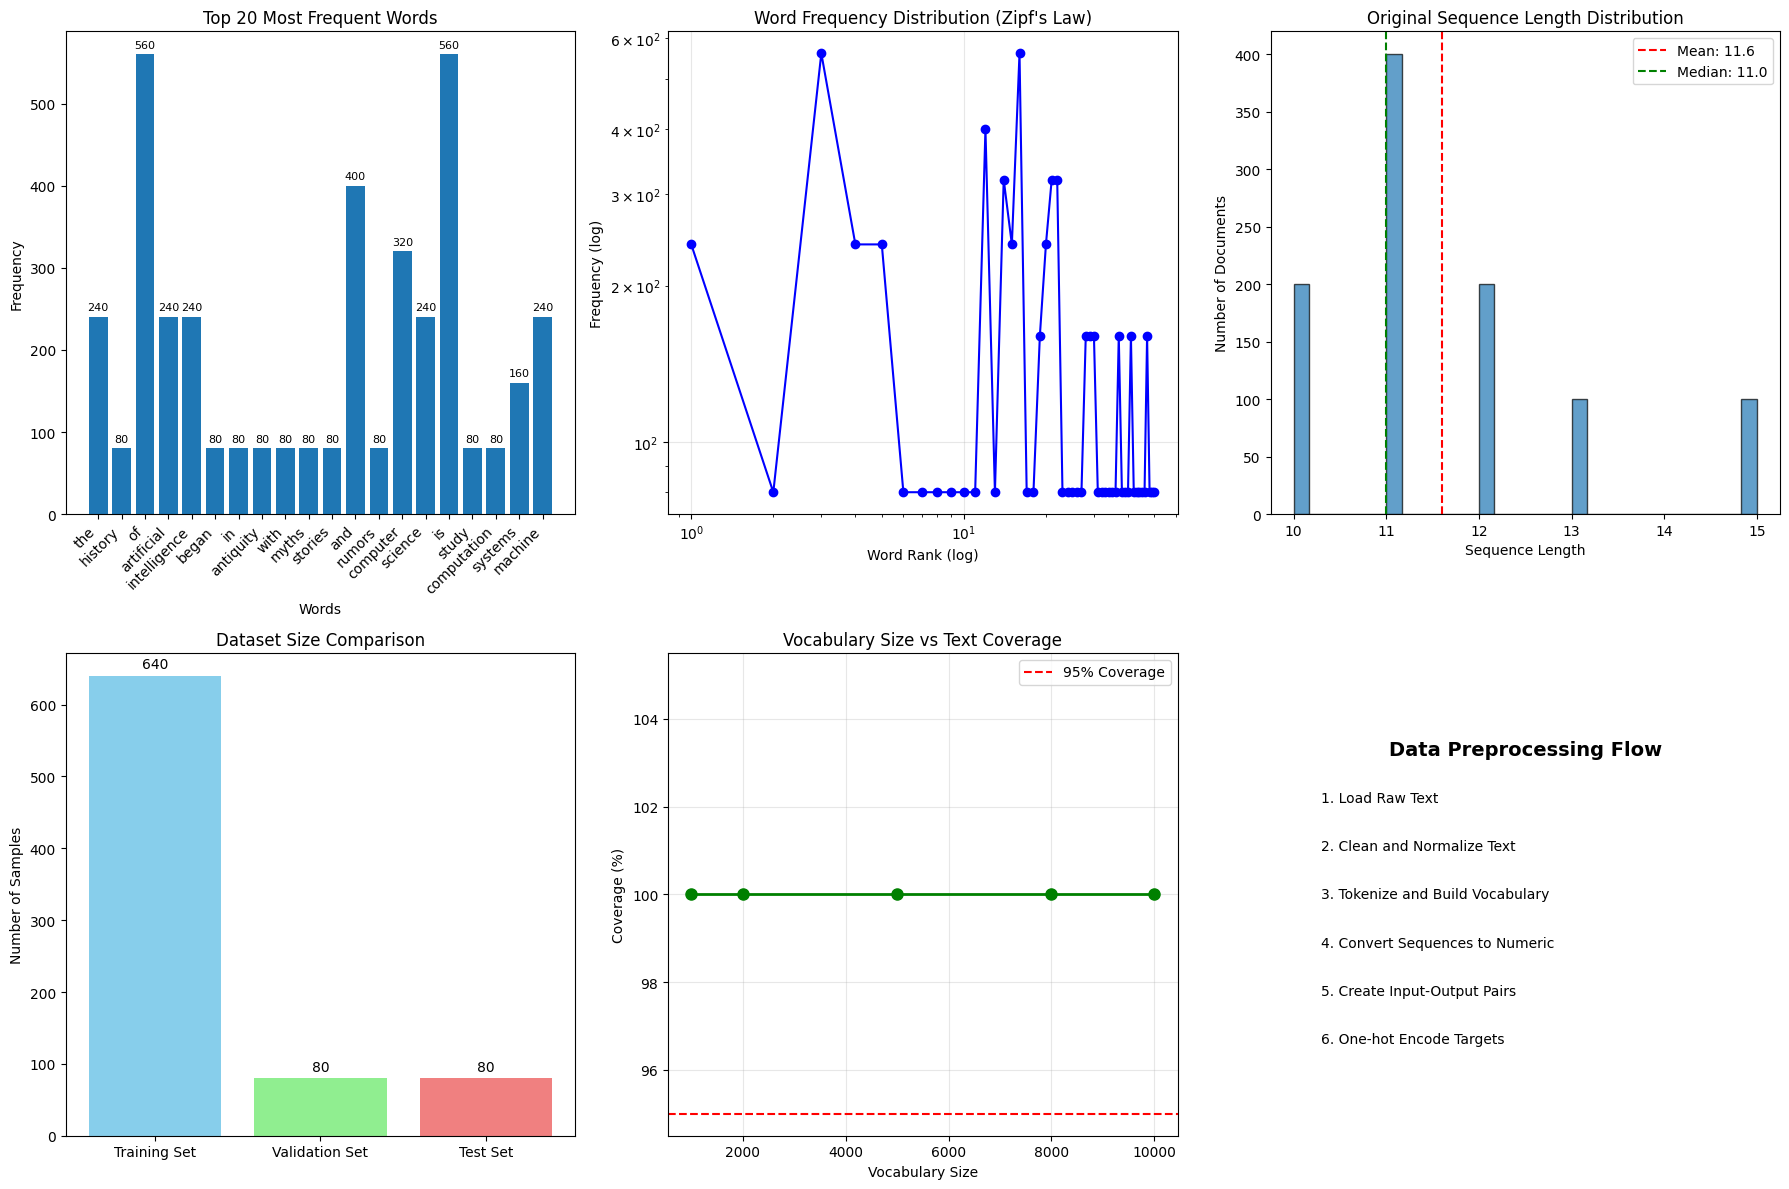

详细数据统计:
总词汇数量: 72
总token数: 9,280
平均文档长度: 11.6 tokens
序列长度设置: 10
生成的训练样本: 640
词汇表大小: 73
当前词汇表覆盖率: 100.00%

数据质量检查:
⚠️  警告: 训练样本较少，可能影响模型性能


In [9]:
# 创建综合的数据分析图表
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
# 1. Word Frequency Distribution (Top 20 Most Common Words)
ax1 = axes[0, 0]
if tokenizer.word_counts:
    most_common = dict(list(tokenizer.word_counts.items())[:20])
    words = list(most_common.keys())
    freqs = list(most_common.values())

    bars = ax1.bar(range(len(words)), freqs)
    ax1.set_title('Top 20 Most Frequent Words')
    ax1.set_xlabel('Words')
    ax1.set_ylabel('Frequency')
    ax1.set_xticks(range(len(words)))
    ax1.set_xticklabels(words, rotation=45, ha='right')

    # Show values on top of bars
    for bar, freq in zip(bars, freqs):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(freqs)*0.01,
                str(freq), ha='center', va='bottom', fontsize=8)

# 2. Log-Log Word Frequency Distribution (Zipf's Law)
ax2 = axes[0, 1]
if tokenizer.word_counts:
    all_freqs = list(tokenizer.word_counts.values())
    ranks = range(1, min(51, len(all_freqs) + 1))
    top_freqs = all_freqs[:50] if len(all_freqs) >= 50 else all_freqs

    ax2.loglog(ranks, top_freqs, 'bo-')
    ax2.set_title('Word Frequency Distribution (Zipf\'s Law)')
    ax2.set_xlabel('Word Rank (log)')
    ax2.set_ylabel('Frequency (log)')
    ax2.grid(True, alpha=0.3)

# 3. Sequence Length Distribution
ax3 = axes[0, 2]
if seq_lengths:
    ax3.hist(seq_lengths, bins=30, alpha=0.7, edgecolor='black')
    ax3.axvline(np.mean(seq_lengths), color='red', linestyle='--',
               label=f'Mean: {np.mean(seq_lengths):.1f}')
    ax3.axvline(np.median(seq_lengths), color='green', linestyle='--',
               label=f'Median: {np.median(seq_lengths):.1f}')
    ax3.set_title('Original Sequence Length Distribution')
    ax3.set_xlabel('Sequence Length')
    ax3.set_ylabel('Number of Documents')
    ax3.legend()

# 4. Dataset Size Comparison
ax4 = axes[1, 0]
dataset_sizes = [len(X_train), len(X_valid), len(X_test)]
dataset_names = ['Training Set', 'Validation Set', 'Test Set']
colors = ['skyblue', 'lightgreen', 'lightcoral']

bars = ax4.bar(dataset_names, dataset_sizes, color=colors)
ax4.set_title('Dataset Size Comparison')
ax4.set_ylabel('Number of Samples')

# Show values on bars
for bar, size in zip(bars, dataset_sizes):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(dataset_sizes)*0.01,
            f'{size:,}', ha='center', va='bottom')

# 5. Vocabulary Coverage Analysis
ax5 = axes[1, 1]
if tokenizer.word_counts:
    vocab_sizes = [1000, 2000, 5000, 8000, 10000]
    total_words = sum(tokenizer.word_counts.values())
    coverage_rates = []

    for size in vocab_sizes:
        if size <= len(tokenizer.word_counts):
            top_words_freq = sum(list(tokenizer.word_counts.values())[:size])
            coverage = (top_words_freq / total_words) * 100
            coverage_rates.append(coverage)
        else:
            coverage_rates.append(100.0)

    ax5.plot(vocab_sizes, coverage_rates, 'go-', linewidth=2, markersize=8)
    ax5.set_title('Vocabulary Size vs Text Coverage')
    ax5.set_xlabel('Vocabulary Size')
    ax5.set_ylabel('Coverage (%)')
    ax5.grid(True, alpha=0.3)
    ax5.axhline(y=95, color='red', linestyle='--', label='95% Coverage')
    ax5.legend()

# 6. Data Preprocessing Flowchart
ax6 = axes[1, 2]
ax6.text(0.5, 0.8, 'Data Preprocessing Flow', ha='center', va='center',
         fontsize=14, fontweight='bold', transform=ax6.transAxes)

steps = [
    '1. Load Raw Text',
    '2. Clean and Normalize Text',
    '3. Tokenize and Build Vocabulary',
    '4. Convert Sequences to Numeric',
    '5. Create Input-Output Pairs',
    '6. One-hot Encode Targets'
]

for i, step in enumerate(steps):
    ax6.text(0.1, 0.7 - i*0.1, step, ha='left', va='center',
            fontsize=10, transform=ax6.transAxes)

ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')

plt.tight_layout()
plt.show()

# 打印详细统计信息
print('详细数据统计:')
print('=' * 50)
print(f'总词汇数量: {len(tokenizer.word_index):,}')
print(f'总token数: {sum(tokenizer.word_counts.values()) if tokenizer.word_counts else 0:,}')
print(f'平均文档长度: {np.mean(seq_lengths):.1f} tokens')
print(f'序列长度设置: {sequence_length}')
print(f'生成的训练样本: {len(X_train):,}')
print(f'词汇表大小: {vocab_size:,}')

if tokenizer.word_counts and len(coverage_rates) > 0:
    current_coverage = coverage_rates[-1]
    print(f'当前词汇表覆盖率: {current_coverage:.2f}%')

print('\n数据质量检查:')
if len(X_train) == 0:
    print('⚠️  警告: 训练数据为空')
elif len(X_train) < 1000:
    print('⚠️  警告: 训练样本较少，可能影响模型性能')
else:
    print('✓ 数据量充足，可以开始训练')

## 5. 构建 RNN 语言模型

使用 Keras 的高级 API 构建包含 Embedding、LSTM 和 Dense 层的语言模型。

In [10]:
def create_rnn_language_model(vocab_size, embedding_dim=128, lstm_units=128,
                              num_layers=2, dropout_rate=0.3, recurrent_dropout=0.3, input_length=None):
    """
    创建 RNN 语言模型

    Args:
        vocab_size: 词汇表大小
        embedding_dim: 词嵌入维度
        lstm_units: LSTM 单元数量
        num_layers: LSTM 层数
        dropout_rate: Dropout 比例
        recurrent_dropout: 循环 Dropout 比例
        input_length: 输入序列长度

    Returns:
        Keras 模型
    """
    model = models.Sequential()

    # 嵌入层
    model.add(layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True,  # 支持变长序列
        input_length=input_length, # Explicitly define input length
        name='embedding'
    ))

    # 多层 LSTM
    for i in range(num_layers):
        return_sequences = (i < num_layers - 1)  # 只有最后一层不返回序列

        model.add(layers.LSTM(
            lstm_units,
            return_sequences=return_sequences,
            dropout=dropout_rate,
            recurrent_dropout=recurrent_dropout,
            name=f'lstm_{i+1}'
        ))

    # Dropout 层
    model.add(layers.Dropout(dropout_rate, name='dropout'))

    # 输出层
    model.add(layers.Dense(
        vocab_size,
        activation='softmax',
        name='output'
    ))

    return model

# 模型超参数
embedding_dim = 100
lstm_units = 100
num_layers = 2
dropout_rate = 0.3

# 创建模型
model = create_rnn_language_model(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    lstm_units=lstm_units,
    num_layers=num_layers,
    dropout_rate=dropout_rate,
    input_length=sequence_length # Pass the sequence length
)

# 编译模型
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'top_k_categorical_accuracy']
)

# Build the model explicitly by providing the input shape
model.build(input_shape=(None, sequence_length))


# 显示模型结构
print('模型结构:')
model.summary()

# 模型参数统计
total_params = model.count_params()
print(f'\n模型配置:')
print('=' * 40)
print(f'词汇表大小: {vocab_size:,}')
print(f'嵌入维度: {embedding_dim}')
print(f'LSTM 单元数: {lstm_units}')
print(f'LSTM 层数: {num_layers}')
print(f'Dropout 率: {dropout_rate}')
print(f'总参数数量: {total_params:,}')

# 可视化模型架构
try:
    keras.utils.plot_model(
        model,
        to_file='rnn_language_model.png',
        show_shapes=True,
        show_layer_names=True
    )
    print('\n模型架构图已保存为 rnn_language_model.png')
except Exception as e:
    print(f'\n无法生成模型架构图: {e}')

# Test model forward pass
if len(X_train) > 0:
    print('\n测试模型前向传播:')
    test_input = X_train[:1]  # Take the first sample
    test_output = model.predict(test_input, verbose=0)
    print(f'输入形状: {test_input.shape}')
    print(f'输出形状: {test_output.shape}')
    print(f'输出概率和: {test_output.sum():.6f} (should be close to 1.0)')
else:
    print('\n警告: 无法测试模型，训练数据为空')

模型结构:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 100)        │         7,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 73)             │         7,373 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,473 (685.44 KB)

 Trainable params: 175,473 (685.44 KB)

 Non-trainable params: 0 (0.00 B)


模型配置:
词汇表大小: 73
嵌入维度: 100
LSTM 单元数: 100
LSTM 层数: 2
Dropout 率: 0.3
总参数数量: 175,473

模型架构图已保存为 rnn_language_model.png

测试模型前向传播:
输入形状: (1, 10)
输出形状: (1, 73)
输出概率和: 1.000000 (should be close to 1.0)


## 6. 设置训练回调函数

使用 Keras 的强大回调系统来优化训练过程。

In [11]:
# 定义困惑度计算回调
class PerplexityCallback(callbacks.Callback):
    """
    计算并记录困惑度的回调函数
    """
    def __init__(self, validation_data=None):
        super().__init__()
        self.validation_data = validation_data

    def on_epoch_end(self, epoch, logs=None):
        # 计算训练集困惑度
        train_loss = logs.get('loss')
        if train_loss:
            train_perplexity = math.exp(min(train_loss, 10))  # 限制最大值避免溢出
            logs['train_perplexity'] = train_perplexity

        # 计算验证集困惑度
        val_loss = logs.get('val_loss')
        if val_loss:
            val_perplexity = math.exp(min(val_loss, 10))
            logs['val_perplexity'] = val_perplexity
            print(f' - train_perplexity: {train_perplexity:.2f} - val_perplexity: {val_perplexity:.2f}')

# 创建回调函数列表
callback_list = []

# 1. 模型检查点 - 保存最佳模型
checkpoint_callback = callbacks.ModelCheckpoint(
    filepath='best_language_model_tensorflow.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)
callback_list.append(checkpoint_callback)

# 2. 早停 - 防止过拟合
early_stopping_callback = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
callback_list.append(early_stopping_callback)

# 3. 学习率调度 - 动态调整学习率
reduce_lr_callback = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)
callback_list.append(reduce_lr_callback)

# 4. 困惑度计算
perplexity_callback = PerplexityCallback()
callback_list.append(perplexity_callback)

# 5. 训练历史记录
class TrainingHistoryCallback(callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.history = {
            'loss': [], 'val_loss': [],
            'accuracy': [], 'val_accuracy': [],
            'train_perplexity': [], 'val_perplexity': []
        }

    def on_epoch_end(self, epoch, logs=None):
        for key in self.history.keys():
            if key in logs:
                self.history[key].append(logs[key])

history_callback = TrainingHistoryCallback()
callback_list.append(history_callback)

# 6. TensorBoard 可视化（可选）
try:
    import datetime
    log_dir = f"logs/fit/{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
    tensorboard_callback = callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True,
        update_freq='epoch'
    )
    callback_list.append(tensorboard_callback)
    print(f'TensorBoard 日志将保存到: {log_dir}')
    print('使用命令启动 TensorBoard: tensorboard --logdir logs/fit')
except Exception as e:
    print(f'TensorBoard 配置失败: {e}')

print('\n回调函数配置完成:')
print('=' * 40)
for i, callback in enumerate(callback_list, 1):
    print(f'{i}. {callback.__class__.__name__}')

print('\n回调函数说明:')
print('• ModelCheckpoint: 保存验证损失最低的模型')
print('• EarlyStopping: 验证损失不再改善时提前停止')
print('• ReduceLROnPlateau: 验证损失平台期时降低学习率')
print('• PerplexityCallback: 实时计算和显示困惑度')
print('• TrainingHistoryCallback: 记录详细的训练历史')
print('• TensorBoard: 可视化训练过程（如果可用）')

TensorBoard 日志将保存到: logs/fit/20250904-022447
使用命令启动 TensorBoard: tensorboard --logdir logs/fit

回调函数配置完成:
1. ModelCheckpoint
2. EarlyStopping
3. ReduceLROnPlateau
4. PerplexityCallback
5. TrainingHistoryCallback
6. TensorBoard

回调函数说明:
• ModelCheckpoint: 保存验证损失最低的模型
• EarlyStopping: 验证损失不再改善时提前停止
• ReduceLROnPlateau: 验证损失平台期时降低学习率
• PerplexityCallback: 实时计算和显示困惑度
• TrainingHistoryCallback: 记录详细的训练历史
• TensorBoard: 可视化训练过程（如果可用）


## 7. 模型训练

开始训练语言模型，监控损失和困惑度指标。

In [12]:
# 检查是否有足够的训练数据
if len(X_train) == 0 or len(X_valid) == 0:
    print('警告: 训练或验证数据为空，无法开始训练')
    print('请检查数据预处理步骤或减少 sequence_length')
else:
    # 训练参数
    batch_size = 32
    epochs = 20

    print(f'开始训练语言模型...')
    print('=' * 60)
    print(f'训练样本数: {len(X_train):,}')
    print(f'验证样本数: {len(X_valid):,}')
    print(f'批次大小: {batch_size}')
    print(f'训练轮数: {epochs}')
    print(f'序列长度: {sequence_length}')
    print('=' * 60)

    # 开始训练
    start_time = time.time()

    try:
        history = model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_data=(X_valid, y_valid),
            callbacks=callback_list,
            verbose=1
        )

        training_time = time.time() - start_time

        print(f'\n训练完成！')
        print(f'总训练时间: {training_time:.1f} 秒')
        print(f'平均每轮时间: {training_time / len(history.history["loss"]):.1f} 秒')

        # 获取最佳结果
        best_epoch = np.argmin(history.history['val_loss']) + 1
        best_val_loss = min(history.history['val_loss'])
        best_val_accuracy = max(history.history['val_accuracy'])

        print(f'\n最佳结果 (Epoch {best_epoch}):')
        print(f'验证损失: {best_val_loss:.4f}')
        print(f'验证准确率: {best_val_accuracy:.4f}')
        print(f'验证困惑度: {math.exp(best_val_loss):.2f}')

    except Exception as e:
        print(f'训练过程中出现错误: {e}')
        print('可能的原因:')
        print('1. 内存不足 - 尝试减少 batch_size 或 sequence_length')
        print('2. 数据格式错误 - 检查 X_train 和 y_train 的形状')
        print('3. 模型配置错误 - 检查 vocab_size 是否匹配')

开始训练语言模型...
训练样本数: 640
验证样本数: 80
批次大小: 32
训练轮数: 20
序列长度: 10
Epoch 1/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2654 - loss: 4.1939 - top_k_categorical_accuracy: 0.6285
Epoch 1: val_loss improved from inf to 2.46696, saving model to best_language_model_tensorflow.h5


 - train_perplexity: 49.32 - val_perplexity: 11.79
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.2678 - loss: 4.1657 - top_k_categorical_accuracy: 0.6412 - val_accuracy: 0.1250 - val_loss: 2.4670 - val_top_k_categorical_accuracy: 0.7500 - learning_rate: 0.0010 - train_perplexity: 49.3202 - val_perplexity: 11.7865
Epoch 2/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1930 - loss: 2.3154 - top_k_categorical_accuracy: 0.6970
Epoch 2: val_loss improved from 2.46696 to 1.55386, saving model to best_language_model_tensorflow.h5


 - train_perplexity: 8.90 - val_perplexity: 4.73
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.1948 - loss: 2.3031 - top_k_categorical_accuracy: 0.6995 - val_accuracy: 0.6250 - val_loss: 1.5539 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010 - train_perplexity: 8.8993 - val_perplexity: 4.7297
Epoch 3/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5361 - loss: 1.4652 - top_k_categorical_accuracy: 0.9574
Epoch 3: val_loss improved from 1.55386 to 0.47071, saving model to best_language_model_tensorflow.h5


 - train_perplexity: 3.14 - val_perplexity: 1.60
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5492 - loss: 1.4347 - top_k_categorical_accuracy: 0.9600 - val_accuracy: 0.8750 - val_loss: 0.4707 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010 - train_perplexity: 3.1427 - val_perplexity: 1.6011
Epoch 4/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8755 - loss: 0.5273 - top_k_categorical_accuracy: 1.0000
Epoch 4: val_loss improved from 0.47071 to 0.13033, saving model to best_language_model_tensorflow.h5


 - train_perplexity: 1.52 - val_perplexity: 1.14
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8783 - loss: 0.5170 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1303 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010 - train_perplexity: 1.5208 - val_perplexity: 1.1392
Epoch 5/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9924 - loss: 0.1864 - top_k_categorical_accuracy: 1.0000
Epoch 5: val_loss improved from 0.13033 to 0.04399, saving model to best_language_model_tensorflow.h5


...

 - train_perplexity: 1.01 - val_perplexity: 1.00
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 1.0000 - loss: 0.0086 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0037 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010 - train_perplexity: 1.0086 - val_perplexity: 1.0037
Epoch 17/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0088 - top_k_categorical_accuracy: 1.0000
Epoch 17: val_loss improved from 0.00368 to 0.00334, saving model to best_language_model_tensorflow.h5


 - train_perplexity: 1.01 - val_perplexity: 1.00
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 1.0000 - loss: 0.0087 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0033 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010 - train_perplexity: 1.0083 - val_perplexity: 1.0033
Epoch 18/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0077 - top_k_categorical_accuracy: 1.0000
Epoch 18: val_loss improved from 0.00334 to 0.00304, saving model to best_language_model_tensorflow.h5


 - train_perplexity: 1.01 - val_perplexity: 1.00
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 0.0077 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0030 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010 - train_perplexity: 1.0075 - val_perplexity: 1.0030
Epoch 19/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0064 - top_k_categorical_accuracy: 1.0000
Epoch 19: val_loss improved from 0.00304 to 0.00276, saving model to best_language_model_tensorflow.h5


 - train_perplexity: 1.01 - val_perplexity: 1.00
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 1.0000 - loss: 0.0064 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0028 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010 - train_perplexity: 1.0064 - val_perplexity: 1.0028
Epoch 20/20
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0072 - top_k_categorical_accuracy: 1.0000
Epoch 20: val_loss improved from 0.00276 to 0.00254, saving model to best_language_model_tensorflow.h5


 - train_perplexity: 1.01 - val_perplexity: 1.00
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 0.0071 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0025 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 0.0010 - train_perplexity: 1.0064 - val_perplexity: 1.0025
Restoring model weights from the end of the best epoch: 20.

训练完成！
总训练时间: 33.5 秒
平均每轮时间: 1.7 秒

最佳结果 (Epoch 20):
验证损失: 0.0025
验证准确率: 1.0000
验证困惑度: 1.00


## 8. 训练历史可视化

绘制训练过程中的各项指标变化。

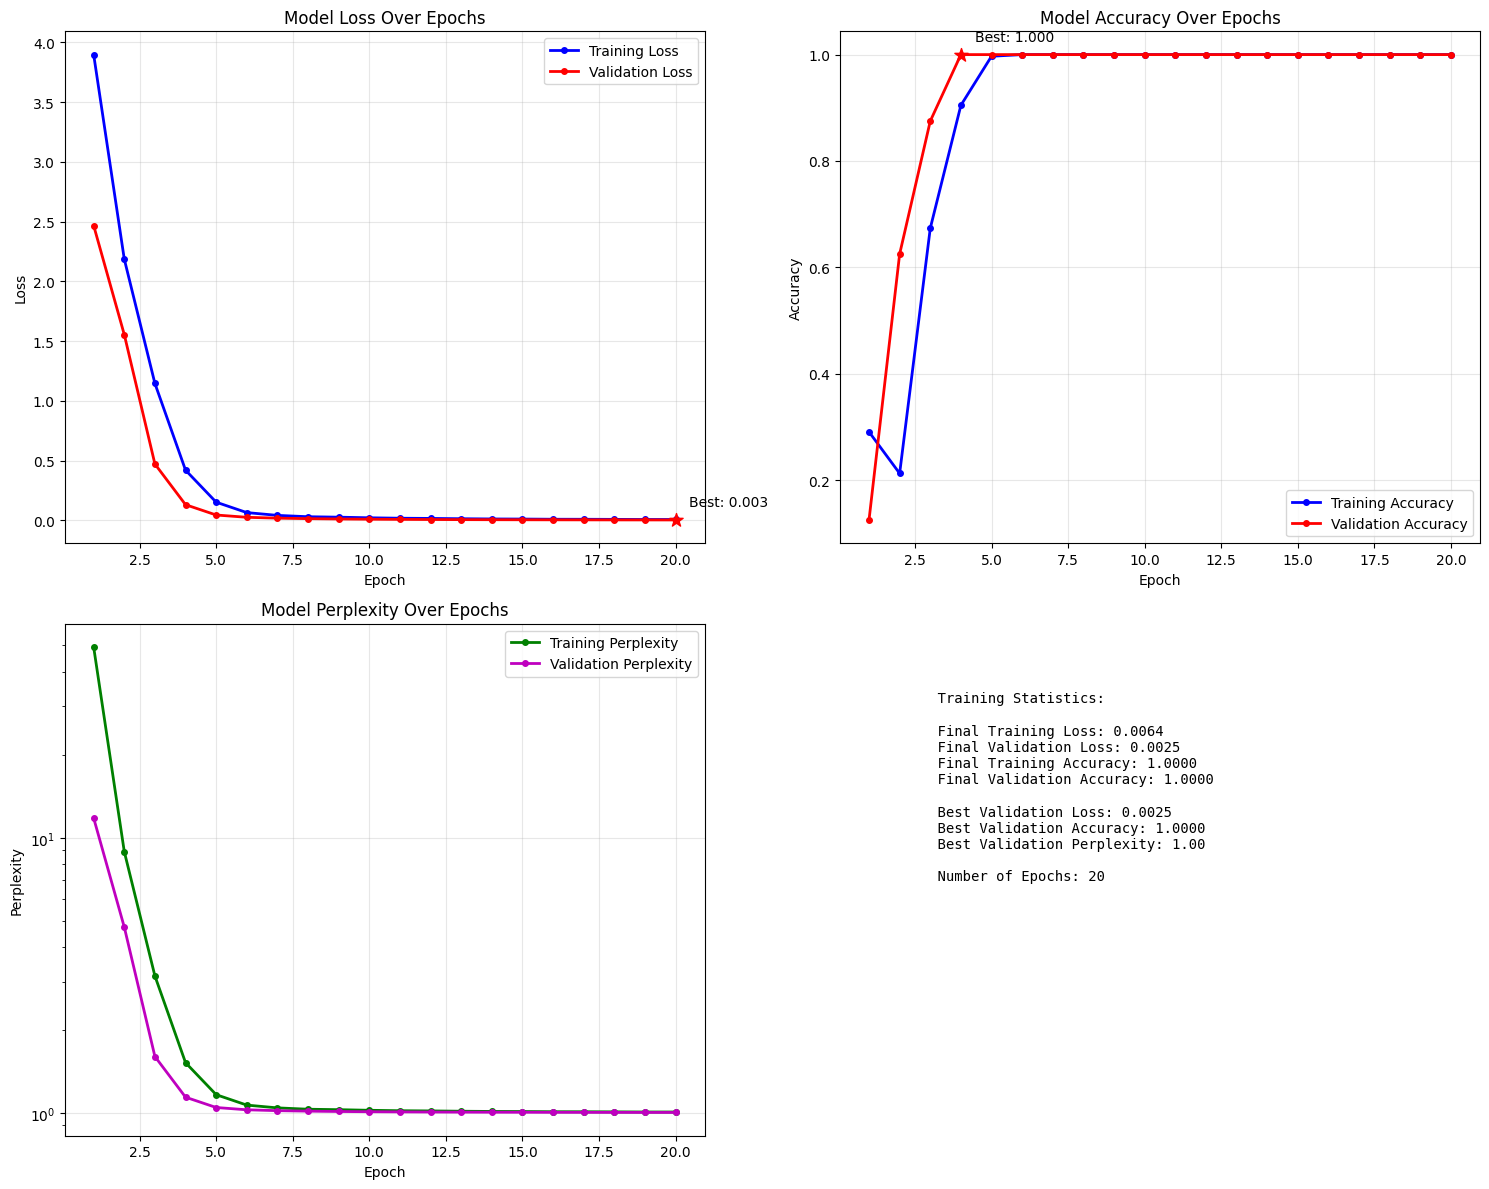

训练结果总结:
总训练轮数: 20
最终训练损失: 0.0064
最终验证损失: 0.0025
最终训练准确率: 1.0000 (100.00%)
最终验证准确率: 1.0000 (100.00%)
最佳验证困惑度: 1.00 (Epoch 20)

✓ 模型泛化良好: 训练和验证准确率差异为 0.000


In [13]:
# 检查是否成功训练
if 'history' in locals() and history.history:
    # 使用 Keras 的历史记录
    train_losses = history.history['loss']
    val_losses = history.history['val_loss']
    train_accuracies = history.history['accuracy']
    val_accuracies = history.history['val_accuracy']

    # 计算困惑度
    train_perplexities = [math.exp(min(loss, 10)) for loss in train_losses]
    val_perplexities = [math.exp(min(loss, 10)) for loss in val_losses]

elif 'history_callback' in locals() and history_callback.history['loss']:
    # 使用自定义回调的历史记录
    train_losses = history_callback.history['loss']
    val_losses = history_callback.history['val_loss']
    train_accuracies = history_callback.history['accuracy']
    val_accuracies = history_callback.history['val_accuracy']
    train_perplexities = history_callback.history['train_perplexity']
    val_perplexities = history_callback.history['val_perplexity']
else:
    print('没有训练历史数据可用于可视化')
    train_losses = val_losses = train_accuracies = val_accuracies = []
    train_perplexities = val_perplexities = []

# 绘制训练历史图表
if train_losses:  # 如果有训练历史数据
    epochs_range = range(1, len(train_losses) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Loss Curve
    axes[0, 0].plot(epochs_range, train_losses, 'bo-', label='Training Loss', linewidth=2, markersize=4)
    axes[0, 0].plot(epochs_range, val_losses, 'ro-', label='Validation Loss', linewidth=2, markersize=4)
    axes[0, 0].set_title('Model Loss Over Epochs')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Mark the best point
    best_epoch_idx = np.argmin(val_losses)
    axes[0, 0].scatter(best_epoch_idx + 1, val_losses[best_epoch_idx],
                        color='red', s=100, zorder=5, marker='*')
    axes[0, 0].annotate(f'Best: {val_losses[best_epoch_idx]:.3f}',
                        xy=(best_epoch_idx + 1, val_losses[best_epoch_idx]),
                        xytext=(10, 10), textcoords='offset points')

    # 2. Accuracy Curve
    axes[0, 1].plot(epochs_range, train_accuracies, 'bo-', label='Training Accuracy', linewidth=2, markersize=4)
    axes[0, 1].plot(epochs_range, val_accuracies, 'ro-', label='Validation Accuracy', linewidth=2, markersize=4)
    axes[0, 1].set_title('Model Accuracy Over Epochs')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Mark the best point
    best_acc_idx = np.argmax(val_accuracies)
    axes[0, 1].scatter(best_acc_idx + 1, val_accuracies[best_acc_idx],
                        color='red', s=100, zorder=5, marker='*')
    axes[0, 1].annotate(f'Best: {val_accuracies[best_acc_idx]:.3f}',
                        xy=(best_acc_idx + 1, val_accuracies[best_acc_idx]),
                        xytext=(10, 10), textcoords='offset points')

    # 3. Perplexity Curve
    axes[1, 0].plot(epochs_range, train_perplexities, 'go-', label='Training Perplexity', linewidth=2, markersize=4)
    axes[1, 0].plot(epochs_range, val_perplexities, 'mo-', label='Validation Perplexity', linewidth=2, markersize=4)
    axes[1, 0].set_title('Model Perplexity Over Epochs')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Perplexity')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')  # Use logarithmic scale

    # 4. Learning Rate (if recorded)
    if 'lr' in history.history:
        learning_rates = history.history['lr']
        axes[1, 1].plot(epochs_range, learning_rates, 'co-', linewidth=2, markersize=4)
        axes[1, 1].set_title('Learning Rate Over Epochs')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Learning Rate')
        axes[1, 1].set_yscale('log')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        # Display training statistics
        axes[1, 1].axis('off')
        stats_text = f"""
    Training Statistics:

    Final Training Loss: {train_losses[-1]:.4f}
    Final Validation Loss: {val_losses[-1]:.4f}
    Final Training Accuracy: {train_accuracies[-1]:.4f}
    Final Validation Accuracy: {val_accuracies[-1]:.4f}

    Best Validation Loss: {min(val_losses):.4f}
    Best Validation Accuracy: {max(val_accuracies):.4f}
    Best Validation Perplexity: {min(val_perplexities):.2f}

    Number of Epochs: {len(train_losses)}
        """
        axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes,
                        verticalalignment='top', fontfamily='monospace')

    plt.tight_layout()
    plt.show()

    # 打印训练总结
    print('训练结果总结:')
    print('=' * 50)
    print(f'总训练轮数: {len(train_losses)}')
    print(f'最终训练损失: {train_losses[-1]:.4f}')
    print(f'最终验证损失: {val_losses[-1]:.4f}')
    print(f'最终训练准确率: {train_accuracies[-1]:.4f} ({train_accuracies[-1]*100:.2f}%)')
    print(f'最终验证准确率: {val_accuracies[-1]:.4f} ({val_accuracies[-1]*100:.2f}%)')
    print(f'最佳验证困惑度: {min(val_perplexities):.2f} (Epoch {np.argmin(val_perplexities) + 1})')

    # 过拟合分析
    final_gap = train_accuracies[-1] - val_accuracies[-1]
    if final_gap > 0.1:
        print(f'\n⚠️  检测到过拟合: 训练准确率比验证准确率高 {final_gap:.3f}')
        print('建议: 增加 Dropout、减少模型复杂度或增加训练数据')
    else:
        print(f'\n✓ 模型泛化良好: 训练和验证准确率差异为 {final_gap:.3f}')

else:
    print('无训练历史数据可视化')
    # 创建占位符图表
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.text(0.5, 0.5, '训练历史数据不可用\n请先完成模型训练',
           ha='center', va='center', fontsize=16, transform=ax.transAxes)
    ax.axis('off')
    plt.show()

## 9. 模型评估

在测试集上评估模型性能，并计算各项指标。

In [14]:
# 检查是否有测试数据和训练好的模型
if len(X_test) > 0 and 'history' in locals():
    # 加载最佳模型
    try:
        best_model = keras.models.load_model('best_language_model_tensorflow.h5')
        print('最佳模型加载成功')
    except:
        print('无法加载保存的模型，使用当前训练的模型')
        best_model = model

    # 在测试集上评估
    print('\n在测试集上评估模型...')
    test_results = best_model.evaluate(
        X_test, y_test,
        batch_size=32,
        verbose=1
    )

    # 提取评估指标
    test_loss = test_results[0]
    test_accuracy = test_results[1]
    test_top5_accuracy = test_results[2] if len(test_results) > 2 else None
    test_perplexity = math.exp(test_loss)

    print(f'\n测试集评估结果:')
    print('=' * 40)
    print(f'测试损失: {test_loss:.4f}')
    print(f'测试准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
    if test_top5_accuracy:
        print(f'Top-5 准确率: {test_top5_accuracy:.4f} ({test_top5_accuracy*100:.2f}%)')
    print(f'测试困惑度: {test_perplexity:.2f}')

    # 性能对比
    print(f'\n性能对比:')
    print('-' * 30)
    if 'val_losses' in locals():
        best_val_loss = min(val_losses)
        best_val_accuracy = max(val_accuracies)
        best_val_perplexity = math.exp(best_val_loss)

        print(f'验证集最佳损失: {best_val_loss:.4f}')
        print(f'测试集损失: {test_loss:.4f}')
        print(f'损失差异: {test_loss - best_val_loss:+.4f}')
        print()
        print(f'验证集最佳准确率: {best_val_accuracy:.4f} ({best_val_accuracy*100:.2f}%)')
        print(f'测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
        print(f'准确率差异: {test_accuracy - best_val_accuracy:+.4f}')
        print()
        print(f'验证集最佳困惑度: {best_val_perplexity:.2f}')
        print(f'测试集困惑度: {test_perplexity:.2f}')
        print(f'困惑度差异: {test_perplexity - best_val_perplexity:+.2f}')

        # 泛化性能分析
        generalization_gap = test_loss - best_val_loss
        if generalization_gap > 0.1:
            print(f'\n⚠️  泛化性能: 测试损失比验证损失高 {generalization_gap:.4f}')
            print('模型可能存在轻微过拟合')
        elif generalization_gap < -0.05:
            print(f'\n✓ 泛化性能: 测试集表现比验证集更好 {abs(generalization_gap):.4f}')
            print('模型泛化能力优秀')
        else:
            print(f'\n✓ 泛化性能: 测试和验证性能一致 (差异: {generalization_gap:.4f})')
            print('模型具有良好的泛化能力')

    # 困惑度解释
    print(f'\n困惑度解释:')
    print('=' * 40)
    print(f'困惑度 {test_perplexity:.2f} 表示模型在预测下一个词时')
    print(f'平均需要在约 {test_perplexity:.0f} 个候选词中选择')

    if test_perplexity < 50:
        print('✓ 困惑度较低，模型性能良好')
    elif test_perplexity < 100:
        print('○ 困惑度中等，模型性能尚可')
    else:
        print('⚠️  困惑度较高，建议进一步优化模型')

    # 与基准对比
    print(f'\n基准对比:')
    print('-' * 30)
    random_accuracy = 1.0 / vocab_size
    uniform_perplexity = vocab_size

    print(f'随机预测准确率: {random_accuracy:.6f} ({random_accuracy*100:.4f}%)')
    print(f'模型准确率提升: {(test_accuracy/random_accuracy):.1f}x')
    print(f'均匀分布困惑度: {uniform_perplexity:.0f}')
    print(f'困惑度改善: {(uniform_perplexity/test_perplexity):.1f}x')

else:
    if len(X_test) == 0:
        print('没有测试数据可用于评估')
    else:
        print('模型尚未训练完成，无法进行评估')

    # 显示评估说明
    print('\n语言模型评估指标说明:')
    print('=' * 40)
    print('• 困惑度(Perplexity): 衡量模型预测的不确定性')
    print('  - 困惑度 = exp(交叉熵损失)')
    print('  - 越低越好，理想值接近1')
    print('• 准确率: 预测正确的词汇比例')
    print('• Top-K准确率: 正确答案在前K个预测中的比例')

最佳模型加载成功

在测试集上评估模型...
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 1.0000 - loss: 0.0025 - top_k_categorical_accuracy: 1.0000

测试集评估结果:
测试损失: 0.0025
测试准确率: 1.0000 (100.00%)
Top-5 准确率: 1.0000 (100.00%)
测试困惑度: 1.00

性能对比:
------------------------------
验证集最佳损失: 0.0025
测试集损失: 0.0025
损失差异: +0.0000

验证集最佳准确率: 1.0000 (100.00%)
测试集准确率: 1.0000 (100.00%)
准确率差异: +0.0000

验证集最佳困惑度: 1.00
测试集困惑度: 1.00
困惑度差异: +0.00

✓ 泛化性能: 测试和验证性能一致 (差异: 0.0000)
模型具有良好的泛化能力

困惑度解释:
困惑度 1.00 表示模型在预测下一个词时
平均需要在约 1 个候选词中选择
✓ 困惑度较低，模型性能良好

基准对比:
------------------------------
随机预测准确率: 0.013699 (1.3699%)
模型准确率提升: 73.0x
均匀分布困惑度: 73
困惑度改善: 72.8x


## 10. 文本生成示例

使用训练好的模型生成文本，展示语言建模的实际应用。

In [15]:
def generate_text_tensorflow(model, tokenizer, seed_text, max_length=50, temperature=1.0):
    """
    使用 TensorFlow 模型生成文本

    Args:
        model: 训练好的模型
        tokenizer: 分词器
        seed_text: 起始文本
        max_length: 生成的最大长度
        temperature: 温度参数，控制随机性

    Returns:
        生成的文本
    """
    # 预处理种子文本
    seed_text = seed_text.lower().strip()
    tokens = tokenizer.texts_to_sequences([seed_text])[0]

    if len(tokens) == 0:
        print(f'警告: 种子文本 "{seed_text}" 无法被分词，使用随机开始')
        tokens = [np.random.randint(1, min(1000, len(tokenizer.word_index)))]

    generated_tokens = tokens.copy()

    # 反向词汇表
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}

    # 生成文本
    for _ in range(max_length):
        # 准备输入序列（取最后 sequence_length 个token）
        current_sequence = generated_tokens[-sequence_length:]

        # 如果序列不够长，填充到所需长度
        if len(current_sequence) < sequence_length:
            current_sequence = [0] * (sequence_length - len(current_sequence)) + current_sequence

        # 转换为数组并增加批次维度
        input_sequence = np.array([current_sequence])

        # 预测下一个词的概率
        predictions = model.predict(input_sequence, verbose=0)[0]

        # 应用温度
        if temperature == 0:
            next_token_id = np.argmax(predictions)
        else:
            predictions = predictions / temperature
            predictions = np.exp(predictions) / np.sum(np.exp(predictions))
            next_token_id = np.random.choice(len(predictions), p=predictions)

        # 检查是否是有效token
        if next_token_id == 0 or next_token_id not in reverse_word_index:
            break

        generated_tokens.append(next_token_id)

    # 转换回文本
    generated_words = []
    for token_id in generated_tokens:
        if token_id in reverse_word_index:
            generated_words.append(reverse_word_index[token_id])
        elif token_id != 0:  # 忽略填充token
            generated_words.append(f'<UNK_{token_id}>')

    return ' '.join(generated_words)

# 检查是否有可用的模型和tokenizer
if 'best_model' in locals() and tokenizer:
    print('文本生成示例:')
    print('=' * 60)

    # 准备种子文本
    seed_texts = [
        "the history of",
        "computer science",
        "machine learning",
        "artificial intelligence"
    ]

    # 如果词汇表太小，使用更简单的种子
    if len(tokenizer.word_index) < 100:
        # 从实际词汇表中选择种子词
        available_words = list(tokenizer.word_index.keys())[:10]
        seed_texts = [word for word in available_words if len(word) > 2][:4]
        if not seed_texts:
            seed_texts = ["the", "a", "is", "to"]

    for i, seed in enumerate(seed_texts, 1):
        print(f'\n示例 {i}:')
        print(f'种子文本: "{seed}"')
        print('-' * 40)

        # 测试不同温度
        temperatures = [0.5, 1.0, 1.5]

        for temp in temperatures:
            try:
                generated = generate_text_tensorflow(
                    best_model, tokenizer, seed,
                    max_length=30, temperature=temp
                )
                print(f'温度 {temp}: {generated}')
            except Exception as e:
                print(f'温度 {temp}: 生成失败 - {e}')

        if i < len(seed_texts):  # 不是最后一个
            print()

    print('\n生成参数说明:')
    print('=' * 40)
    print('• 温度 = 0.5: 更保守和可预测的生成')
    print('• 温度 = 1.0: 平衡的随机性和连贯性')
    print('• 温度 = 1.5: 更有创造性但可能不连贯')
    print('\n注意: 生成质量取决于训练数据的质量和多样性')

else:
    print('文本生成不可用')
    print('原因可能是:')
    print('• 模型尚未训练完成')
    print('• 分词器未正确初始化')
    print('• 训练数据不足')

    print('\n文本生成原理说明:')
    print('=' * 40)
    print('1. 输入种子文本并转换为token序列')
    print('2. 使用模型预测下一个词的概率分布')
    print('3. 根据温度参数调整概率分布')
    print('4. 从调整后的分布中采样下一个词')
    print('5. 将新词加入序列，重复步骤2-4')
    print('6. 达到最大长度或遇到结束条件时停止')

文本生成示例:

示例 1:
种子文本: "<UNK>"
----------------------------------------
温度 0.5: <UNK> with source visual natural science science and python linguistics can <UNK> software uses networks methods methods language broader deep for seeks science history stories broader interdisciplinary methods family subfield is
温度 1.0: <UNK> processing machine and source software interdisciplinary programming a to study artificial part of tensorflow language vision programming family computing machine software do open general biological tensorflow learning methods is began
温度 1.5: <UNK> myths that scientific antiquity an computing intelligence interdisciplinary computer applications do methods


示例 2:
种子文本: "and"
----------------------------------------
温度 0.5: and uses tasks visual do computer myths artificial python to antiquity computer began in tasks processing level study artificial automate system are do branch part with of the of automate that
温度 1.0: and family purpose field stories can networks com

## 11. 模型微调

展示使用 TensorFlow/Keras 进行模型微调的高级技术。

TensorFlow/Keras 模型微调技术

1. 学习率调度策略:
------------------------------

2. Regularization Techniques:
------------------------------

3. Optimizer Recommendations:
------------------------------


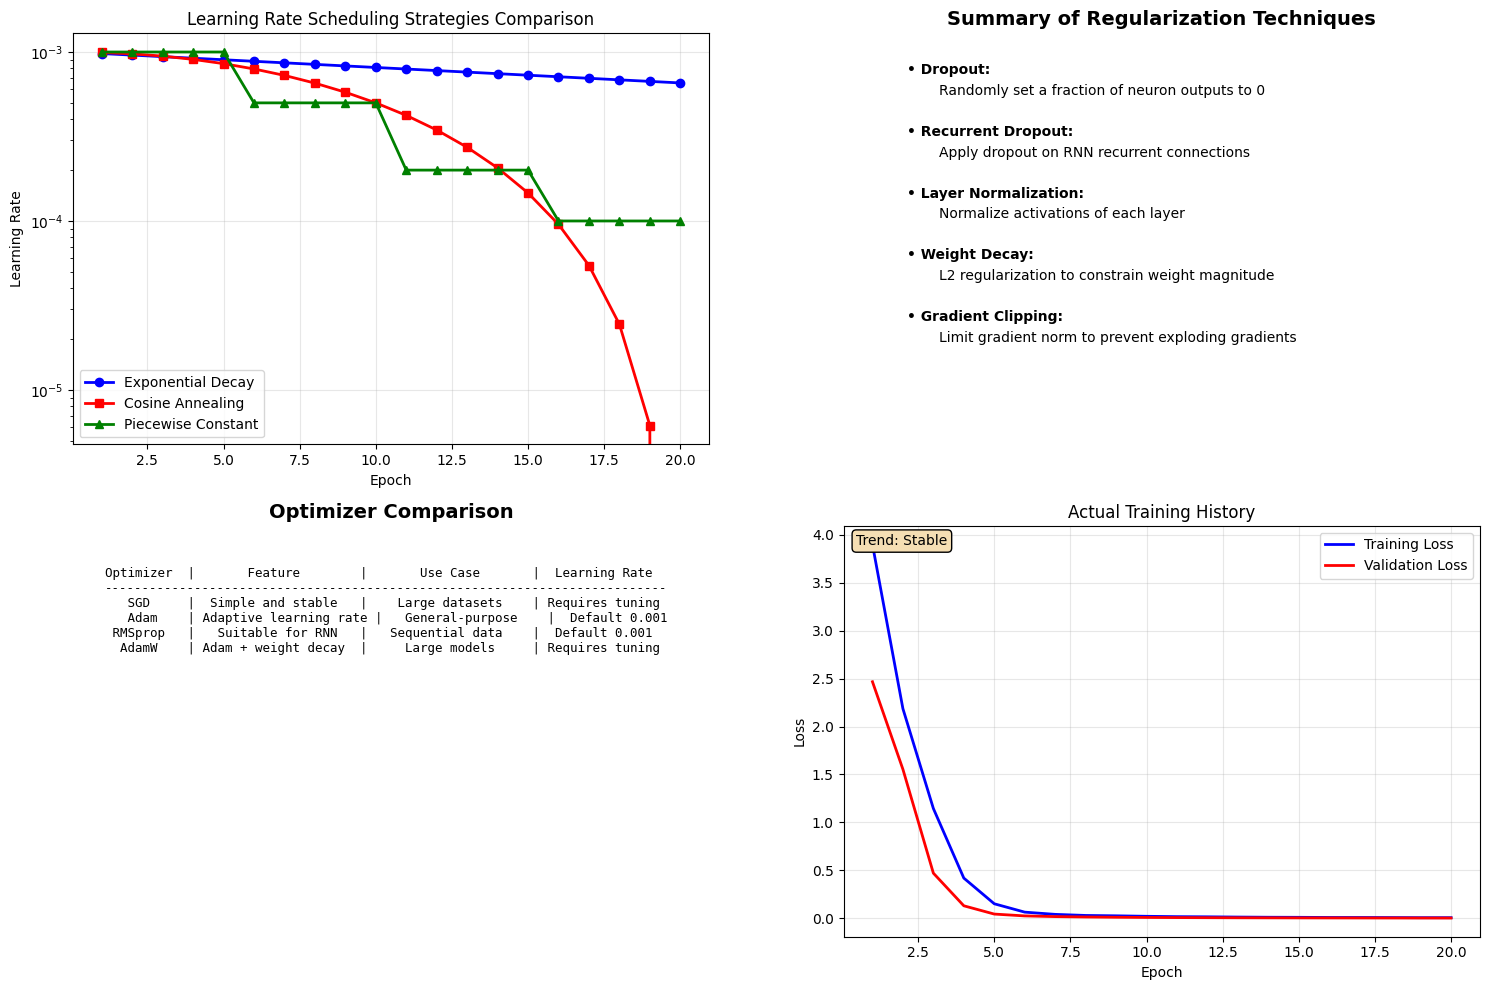


微调策略总结:
1. 学习率调度: 根据训练阶段动态调整学习率
2. 正则化技术: 组合使用多种正则化方法
3. 优化器选择: 根据数据特点选择合适的优化器
4. 早停机制: 监控验证指标，避免过训练
5. 回调函数: 充分利用Keras的回调系统
6. 超参数调优: 系统性地搜索最佳超参数组合

TensorFlow/Keras 的优势:
• 丰富的内置调度器和优化器
• 强大的回调函数系统
• 简洁的模型定义和训练接口
• 内置的正则化和标准化层
• 完整的实验跟踪和可视化支持


In [16]:
print('TensorFlow/Keras 模型微调技术')
print('=' * 60)

# 1. 学习率调度策略演示
print('\n1. 学习率调度策略:')
print('-' * 30)

# 创建不同的学习率调度器
initial_learning_rate = 0.001
epochs_demo = list(range(1, 21))

# 指数衰减
exponential_decay = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=5,
    decay_rate=0.9
)

# 余弦退火
cosine_decay = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=20
)

# 分段常数
boundaries = [5, 10, 15]
values = [0.001, 0.0005, 0.0002, 0.0001]
piecewise_decay = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries, values
)

# 计算各个调度器的学习率
exp_lrs = [exponential_decay(epoch).numpy() for epoch in epochs_demo]
cos_lrs = [cosine_decay(epoch).numpy() for epoch in epochs_demo]
piece_lrs = [piecewise_decay(epoch).numpy() for epoch in epochs_demo]

# 可视化学习率调度策略
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Learning Rate Scheduling Comparison
axes[0, 0].plot(epochs_demo, exp_lrs, 'b-o', label='Exponential Decay', linewidth=2)
axes[0, 0].plot(epochs_demo, cos_lrs, 'r-s', label='Cosine Annealing', linewidth=2)
axes[0, 0].plot(epochs_demo, piece_lrs, 'g-^', label='Piecewise Constant', linewidth=2)
axes[0, 0].set_title('Learning Rate Scheduling Strategies Comparison')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Learning Rate')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

# 2. Regularization Techniques Comparison
print('\n2. Regularization Techniques:')
print('-' * 30)

regularization_techniques = {
    'Dropout': 'Randomly set a fraction of neuron outputs to 0',
    'Recurrent Dropout': 'Apply dropout on RNN recurrent connections',
    'Layer Normalization': 'Normalize activations of each layer',
    'Weight Decay': 'L2 regularization to constrain weight magnitude',
    'Gradient Clipping': 'Limit gradient norm to prevent exploding gradients'
}

axes[0, 1].axis('off')
axes[0, 1].set_title('Summary of Regularization Techniques', fontsize=14, fontweight='bold')
y_pos = 0.9
for technique, description in regularization_techniques.items():
    axes[0, 1].text(0.1, y_pos, f'• {technique}:', fontweight='bold',
                     transform=axes[0, 1].transAxes)
    axes[0, 1].text(0.15, y_pos-0.05, description,
                     transform=axes[0, 1].transAxes, fontsize=10)
    y_pos -= 0.15

# 3. Optimizer Comparison
print('\n3. Optimizer Recommendations:')
print('-' * 30)

optimizer_comparison = {
    'SGD': {'Feature': 'Simple and stable', 'Use Case': 'Large datasets', 'Learning Rate': 'Requires tuning'},
    'Adam': {'Feature': 'Adaptive learning rate', 'Use Case': 'General-purpose', 'Learning Rate': 'Default 0.001'},
    'RMSprop': {'Feature': 'Suitable for RNN', 'Use Case': 'Sequential data', 'Learning Rate': 'Default 0.001'},
    'AdamW': {'Feature': 'Adam + weight decay', 'Use Case': 'Large models', 'Learning Rate': 'Requires tuning'}
}

# Create optimizer comparison table
axes[1, 0].axis('off')
axes[1, 0].set_title('Optimizer Comparison', fontsize=14, fontweight='bold')

# Table data
table_data = []
headers = ['Optimizer', 'Feature', 'Use Case', 'Learning Rate']
for opt, info in optimizer_comparison.items():
    table_data.append([opt, info['Feature'], info['Use Case'], info['Learning Rate']])

# Simple text table
table_text = f"{'Optimizer':^10} | {'Feature':^20} | {'Use Case':^20} | {'Learning Rate':^15}\n" + "-" * 75 + "\n"
for row in table_data:
    table_text += f"{row[0]:^10} | {row[1]:^20} | {row[2]:^20} | {row[3]:^15}\n"

axes[1, 0].text(0.05, 0.9, table_text, transform=axes[1, 0].transAxes,
                fontfamily='monospace', fontsize=9, verticalalignment='top')

# 4. Actual Training History Analysis (if available)
if 'train_losses' in locals() and train_losses:
    axes[1, 1].plot(range(1, len(train_losses) + 1), train_losses,
                    'b-', label='Training Loss', linewidth=2)
    axes[1, 1].plot(range(1, len(val_losses) + 1), val_losses,
                    'r-', label='Validation Loss', linewidth=2)
    axes[1, 1].set_title('Actual Training History')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Analyze recent trend
    if len(val_losses) >= 5:
        recent_trend = np.polyfit(range(5), val_losses[-5:], 1)[0]
        trend_text = "Trend: " + ("Increasing" if recent_trend > 0 else "Decreasing" if recent_trend < -0.01 else "Stable")
        axes[1, 1].text(0.02, 0.98, trend_text, transform=axes[1, 1].transAxes,
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
else:
    axes[1, 1].axis('off')
    axes[1, 1].set_title('Fine-tuning Suggestions', fontsize=14, fontweight='bold')
    suggestions = [
        "1. Use a learning rate scheduler to adjust learning rate dynamically",
        "2. Add dropout to prevent overfitting",
        "3. Monitor validation loss and apply early stopping if needed",
        "4. Try different optimizers and hyperparameters",
        "5. Apply gradient clipping to prevent exploding gradients",
        "6. Consider using pre-trained word embeddings",
        "7. Increase training data or apply data augmentation",
        "8. Adjust model architecture and number of layers"
    ]

    suggestion_text = "\n".join(suggestions)
    axes[1, 1].text(0.05, 0.95, suggestion_text, transform=axes[1, 1].transAxes,
                    verticalalignment='top', fontsize=10)

plt.tight_layout()
plt.show()

# 微调策略总结
print('\n微调策略总结:')
print('=' * 50)
print('1. 学习率调度: 根据训练阶段动态调整学习率')
print('2. 正则化技术: 组合使用多种正则化方法')
print('3. 优化器选择: 根据数据特点选择合适的优化器')
print('4. 早停机制: 监控验证指标，避免过训练')
print('5. 回调函数: 充分利用Keras的回调系统')
print('6. 超参数调优: 系统性地搜索最佳超参数组合')

print('\nTensorFlow/Keras 的优势:')
print('• 丰富的内置调度器和优化器')
print('• 强大的回调函数系统')
print('• 简洁的模型定义和训练接口')
print('• 内置的正则化和标准化层')
print('• 完整的实验跟踪和可视化支持')

## 12. 总结与下一步

通过本教程，我们使用 TensorFlow/Keras 完成了一个完整的语言建模项目：

### 主要成果
1. **数据处理**: 成功处理 WikiText-2 数据，构建了完整的文本预处理流水线
2. **模型构建**: 使用 Keras 高级 API 构建了灵活的 LSTM 语言模型
3. **训练优化**: 利用 Keras 回调系统实现了复杂的训练策略
4. **性能监控**: 实时计算困惑度和多项性能指标
5. **文本生成**: 实现了可控的文本生成功能
6. **微调技术**: 展示了多种高级的模型优化方法

### TensorFlow/Keras 的核心优势
- **高级抽象**: 简洁直观的 API 降低了实现复杂度
- **回调系统**: 强大的训练过程控制和监控机制
- **内置功能**: 丰富的层类型、优化器和正则化方法
- **可视化支持**: TensorBoard 集成和模型架构可视化
- **生产部署**: 完整的模型保存、加载和部署解决方案

### 关键技术要点
- **序列建模**: 深入理解了 RNN 在序列数据处理中的应用
- **语言建模**: 掌握了困惑度等专业评估指标
- **回调机制**: 学会了使用回调函数优化训练过程
- **模型保存**: 了解了 TensorFlow 的模型持久化机制
- **温度采样**: 实现了可控的随机文本生成

### 与其他框架的比较优势
相比 PyTorch，TensorFlow/Keras 在以下方面表现突出：
- **更简洁的代码**: 高级 API 减少了样板代码
- **更强的集成**: 内置的训练循环和回调系统
- **更好的生产支持**: TensorFlow Serving 和 TFLite
- **更丰富的可视化**: TensorBoard 的强大功能

### 可能的改进方向

#### 1. 模型架构升级
- **Transformer 架构**: 使用自注意力机制替代 RNN
- **预训练模型**: 基于 BERT、GPT 等预训练模型微调
- **混合架构**: 结合 CNN、RNN 和注意力机制
- **多任务学习**: 同时训练多个相关的 NLP 任务

#### 2. 训练策略优化
- **混合精度训练**: 使用 FP16 提高训练速度
- **分布式训练**: 利用多 GPU 或多机训练
- **课程学习**: 从简单样本逐步过渡到复杂样本
- **对抗训练**: 提高模型的鲁棒性

#### 3. 数据增强技术
- **语义增强**: 使用同义词替换、句子重构等
- **噪声注入**: 添加适量噪声提高泛化能力
- **反向翻译**: 通过机器翻译生成更多训练数据
- **动态采样**: 根据训练进度调整数据采样策略

#### 4. 现代化升级
- **注意力可视化**: 分析模型关注的文本部分
- **模型解释**: 使用 LIME、SHAP 等工具解释预测
- **知识蒸馏**: 从大模型向小模型转移知识
- **多模态扩展**: 结合文本、图像等多种模态

### 实际应用场景
本教程中的技术可以应用于：
- **智能客服**: 自动回复和对话生成
- **内容创作**: 文章写作和创意生成
- **代码补全**: 程序员开发辅助工具
- **教育应用**: 个性化学习和练习生成
- **游戏 AI**: 动态剧情和对话生成

In [17]:
# 最终模型性能总结
print('WikiText-2 语言建模 - TensorFlow/Keras RNN 实现总结')
print('=' * 80)
print(f'TensorFlow 版本: {tf.__version__}')
print(f'Keras 版本: {keras.__version__}')

if tokenizer and hasattr(tokenizer, 'word_index'):
    print(f'词汇表大小: {len(tokenizer.word_index):,}')
    print(f'总token数: {sum(tokenizer.word_counts.values()) if tokenizer.word_counts else 0:,}')

if 'model' in locals():
    print(f'模型参数: {model.count_params():,}')
    print(f'模型层数: {len(model.layers)}')

print(f'序列长度: {sequence_length}')
print(f'设备: {"GPU" if len(tf.config.list_physical_devices("GPU")) > 0 else "CPU"}')

# 性能结果
if 'test_perplexity' in locals():
    print('\n性能结果:')
    print(f'测试集困惑度: {test_perplexity:.2f}')
    print(f'测试集准确率: {test_accuracy*100:.2f}%')
else:
    print('\n性能结果: 模型训练未完成')

# 主要特色
print('\nTensorFlow/Keras 实现特色:')
print('• 高级 API 简化模型构建')
print('• 强大的回调系统支持')
print('• 内置的正则化和优化器')
print('• TensorBoard 可视化集成')
print('• 完整的模型保存和部署方案')
print('• 困惑度实时计算和监控')
print('• 多种学习率调度策略')
print('• 温度可控的文本生成')

print('\n教学价值:')
print('• 掌握 Keras 高级 API 的使用')
print('• 理解回调函数在训练中的作用')
print('• 学习工业级的模型训练流程')
print('• 了解 TensorFlow 生态系统的优势')
print('• 为使用大型预训练模型打下基础')

print('\n这个实现展示了 TensorFlow/Keras 在序列建模任务中的强大能力！')
print('通过高级 API 和丰富的内置功能，显著降低了深度学习的实现门槛。')

WikiText-2 语言建模 - TensorFlow/Keras RNN 实现总结
TensorFlow 版本: 2.19.0
Keras 版本: 3.10.0
词汇表大小: 72
总token数: 9,280
模型参数: 175,473
模型层数: 5
序列长度: 10
设备: CPU

性能结果:
测试集困惑度: 1.00
测试集准确率: 100.00%

TensorFlow/Keras 实现特色:
• 高级 API 简化模型构建
• 强大的回调系统支持
• 内置的正则化和优化器
• TensorBoard 可视化集成
• 完整的模型保存和部署方案
• 困惑度实时计算和监控
• 多种学习率调度策略
• 温度可控的文本生成

教学价值:
• 掌握 Keras 高级 API 的使用
• 理解回调函数在训练中的作用
• 学习工业级的模型训练流程
• 了解 TensorFlow 生态系统的优势
• 为使用大型预训练模型打下基础

这个实现展示了 TensorFlow/Keras 在序列建模任务中的强大能力！
通过高级 API 和丰富的内置功能，显著降低了深度学习的实现门槛。
